# HAST Messdaten – Zeitreihenanalyse
**Ziel:** Explorative Datenanalyse der HAST-Messdaten als Grundlage für Anomalieerkennung

**Spalten:** `Timestamp`, `Energy (kWh)`, `Volume flow (l/h)`, `Power (kW)`, `Temperature difference (°C)`, `Flow temperature (°C)`, `Return temperature (°C)`, `Volume (m³)`

## 0 · Setup & Imports

In [25]:
# Installation (einmalig – auskommentieren wenn bereits vorhanden)
!pip install pandas numpy matplotlib seaborn plotly kaleido scipy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Einheitliche Ploteinstellungen
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
sns.set_theme(style='whitegrid')

print('Imports erfolgreich ✓')

Imports erfolgreich ✓


## 1 · Daten laden & bereinigen

In [27]:
# ── ANPASSEN: Pfad zur CSV-Datei (oder Liste mehrerer HASTe) ──────────────────
HAST_DATEIEN = {
    'HAST_01': r"C:\Users\pauli\Documents\Information Systems\2026 SoSe\Projektseminar\projektseminar\data\raw\synthetic\meters\53198226.csv",
    # 'HAST_02': 'pfad/zu/hast_02.csv',
}

# Spaltennamen-Mapping (Originalname → interner Kurzname)
SPALTEN_MAP = {
    'Timestamp':                    'ts',
    'Energy (kWh)':                 'energy_kwh',
    'Volume flow (l/h)':            'flow_lh',
    'Power (kW)':                   'power_kw',
    'Temperature difference (Â°C)': 'delta_t',   # Encoding-Artefakt im Original
    'Temperature difference (°C)':  'delta_t',
    'Flow temperature (Â°C)':       'temp_flow',
    'Flow temperature (°C)':        'temp_flow',
    'Return temperature (Â°C)':     'temp_return',
    'Return temperature (°C)':      'temp_return',
    'Volume (mÂ³)':                 'volume_m3',
    'Volume (m³)':                  'volume_m3',
}

def lade_hast(pfad: str, name: str) -> pd.DataFrame:
    """Lädt eine HAST-CSV und gibt ein bereinigtes DataFrame zurück."""
    df = pd.read_csv(pfad, sep=None, engine='python')  # Auto-Trennzeichen

    # Spaltennamen normalisieren
    df.rename(columns={k: v for k, v in SPALTEN_MAP.items() if k in df.columns}, inplace=True)

    # Timestamp parsen
    df['ts'] = pd.to_datetime(df['ts'])    
    df.set_index('ts', inplace=True)
    df.sort_index(inplace=True)

    # Numerische Spalten erzwingen
    num_cols = ['energy_kwh', 'flow_lh', 'power_kw', 'delta_t', 'temp_flow', 'temp_return', 'volume_m3']
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # HAST-Bezeichnung als Spalte
    df['hast'] = name

    return df


# Alle HASTe laden
dfs = {name: lade_hast(pfad, name) for name, pfad in HAST_DATEIEN.items()} 
df = dfs[list(dfs.keys())[0]]  # Hauptdataframe = erster HAST

print(f'Geladen: {len(df):,} Zeilen | {df.index.min()} → {df.index.max()}')
df.head()

Geladen: 8,760 Zeilen | 2024-01-01 00:00:00 → 2024-12-30 23:00:00


,energy_kwh,flow_lh,power_kw,delta_t,temp_flow,temp_return,volume_m3,hast
ts,,,,,,,,
2024-01-01 00:00:00,1.72,81.0,1.722,18.4,63.1,44.7,0.081,HAST_01
2024-01-01 01:00:00,3.00,68.0,1.281,16.2,62.0,45.8,0.149,HAST_01
2024-01-01 02:00:00,4.53,71.0,1.529,18.5,63.6,45.0,0.220,HAST_01
2024-01-01 03:00:00,5.85,70.0,1.314,16.1,61.8,45.7,0.290,HAST_01
2024-01-01 04:00:00,7.27,77.0,1.429,16.0,61.8,45.8,0.367,HAST_01


## 2 · Datenqualität & Überblick

In [28]:
# ── Fehlende Werte ────────────────────────────────────────────────────────────
missing = df.drop(columns='hast').isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

print('=== Fehlende Werte ===')
print(pd.concat([missing.rename('Anzahl'), missing_pct.rename('%')], axis=1))

# ── Zeitliche Abdeckung & Lücken ─────────────────────────────────────────────
freq = pd.infer_freq(df.index[:50])  # Vermutete Frequenz
print(f'\nZeitstempel-Frequenz (vermutet): {freq}')

zeitdelta = df.index.to_series().diff()
luecken = zeitdelta[zeitdelta > zeitdelta.median() * 2]
print(f'Zeitliche Lücken (> 2× Median-Intervall): {len(luecken)}')
if len(luecken) > 0:
    print(luecken.sort_values(ascending=False).head(10))

# ── Statistik ─────────────────────────────────────────────────────────────────
print('\n=== Deskriptive Statistik ===')
df.drop(columns='hast').describe().round(2)

=== Fehlende Werte ===
             Anzahl    %
energy_kwh        0  0.0
flow_lh           0  0.0
power_kw          0  0.0
delta_t           0  0.0
temp_flow         0  0.0
temp_return       0  0.0
volume_m3         0  0.0

Zeitstempel-Frequenz (vermutet): h
Zeitliche Lücken (> 2× Median-Intervall): 0

=== Deskriptive Statistik ===


,energy_kwh,flow_lh,power_kw,delta_t,temp_flow,temp_return,volume_m3
count,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00
mean,6058.33,58.77,1.39,17.32,58.62,41.30,256.03
std,2481.11,49.87,1.35,3.79,5.05,2.54,109.39
min,1.72,0.00,0.00,11.00,48.40,31.20,0.08
25%,5178.03,0.00,0.00,14.10,54.30,39.80,211.39
50%,6032.46,58.00,1.12,16.50,58.60,41.70,255.04
75%,6919.18,103.00,2.42,20.20,62.90,43.00,300.43
max,12198.85,173.00,5.81,30.10,71.40,49.00,514.82


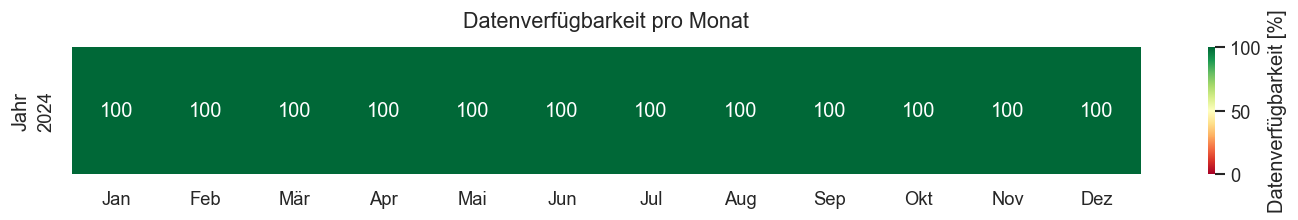

In [29]:
# ── Verfügbarkeit als Heatmap (Monate × Jahre) ───────────────────────────────
verfuegbar = df['power_kw'].notna().resample('ME').mean() * 100
verfuegbar_df = verfuegbar.to_frame(name='verfuegbarkeit')
verfuegbar_df['jahr'] = verfuegbar_df.index.year
verfuegbar_df['monat'] = verfuegbar_df.index.month

pivot = verfuegbar_df.pivot(index='jahr', columns='monat', values='verfuegbarkeit')
monatsnamen = ['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez']
pivot.columns = [monatsnamen[m-1] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(12, max(2, len(pivot) * 0.7)))
sns.heatmap(pivot, ax=ax, cmap='RdYlGn', vmin=0, vmax=100,
            annot=True, fmt='.0f', cbar_kws={'label': 'Datenverfügbarkeit [%]'})
ax.set_title('Datenverfügbarkeit pro Monat', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Jahr')
plt.tight_layout()
plt.show()

## 3 · Zeitreihen-Überblick (alle Kanäle)

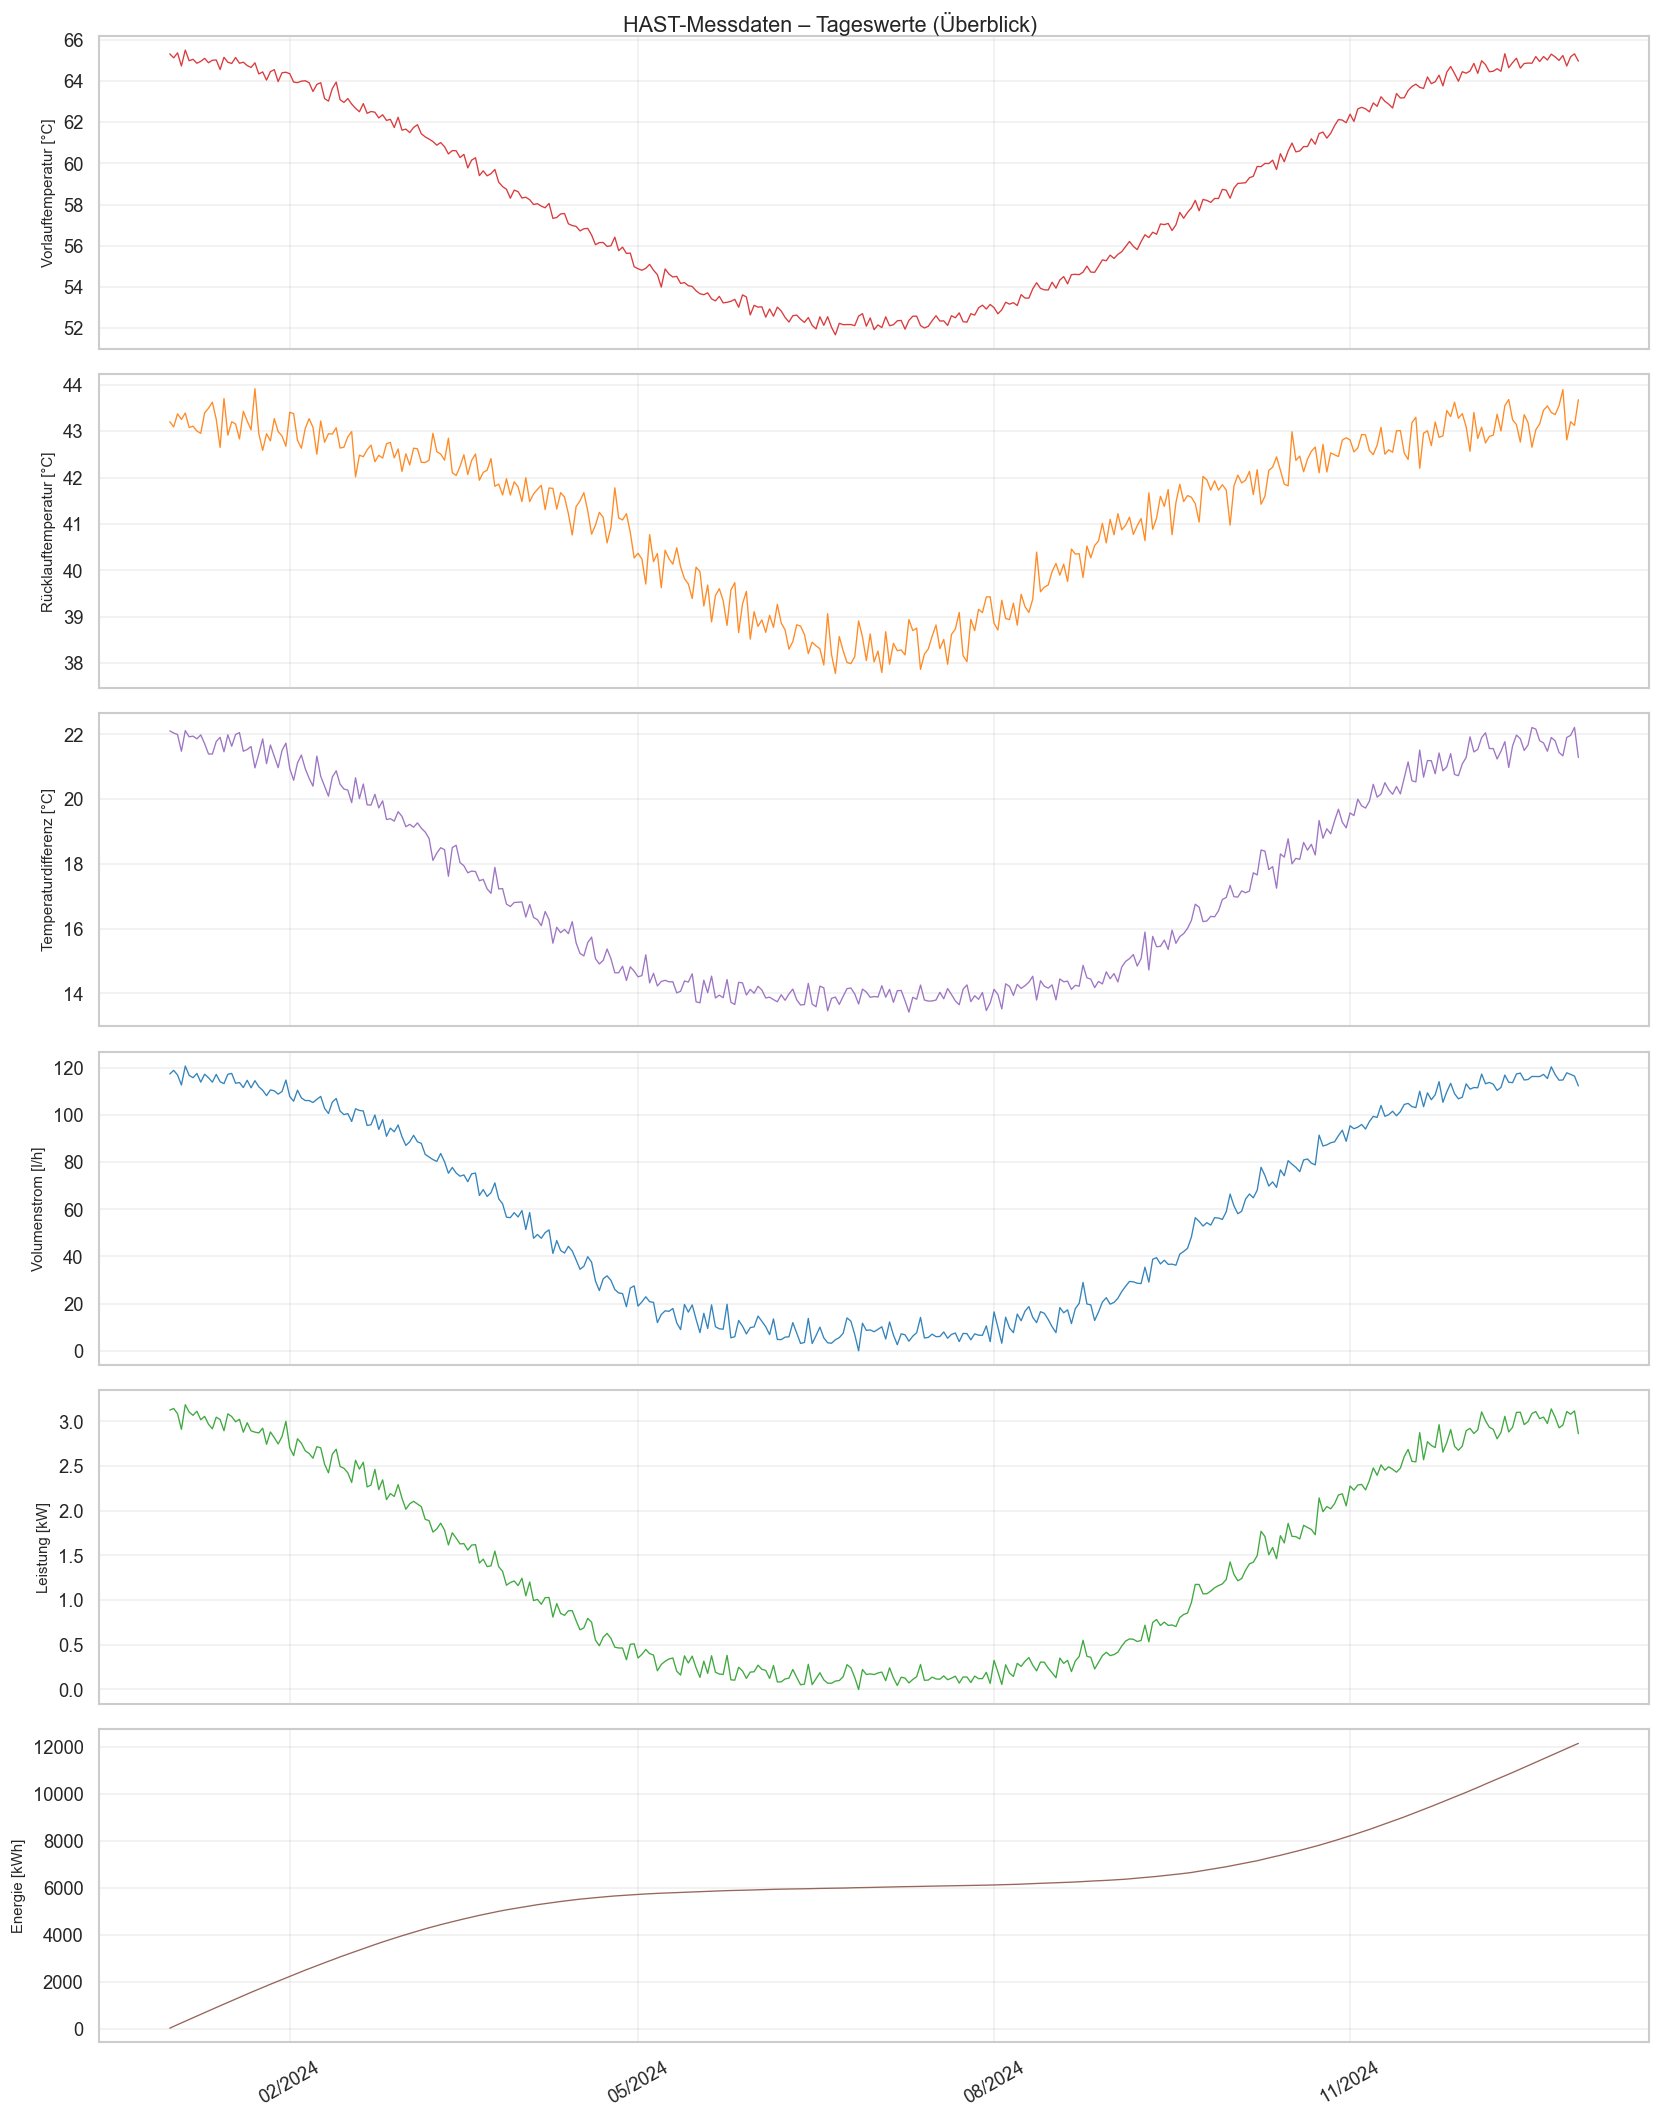

In [33]:

# Tageswerte
df_tag = df.resample('D').mean(numeric_only=True)

KANALE = [
    ('temp_flow',   'Vorlauftemperatur [°C]',   '#d62728'),
    ('temp_return', 'Rücklauftemperatur [°C]',  '#ff7f0e'),
    ('delta_t',     'Temperaturdifferenz [°C]',  '#9467bd'),
    ('flow_lh',     'Volumenstrom [l/h]',         '#1f77b4'),
    ('power_kw',    'Leistung [kW]',              '#2ca02c'),
    ('energy_kwh',  'Energie [kWh]',              '#8c564b'),
]

# Nur vorhandene Kanäle
kanale_vorhanden = [(c, l, f) for c, l, f in KANALE if c in df_tag.columns]

fig, axes = plt.subplots(len(kanale_vorhanden), 1, figsize=(14, 3 * len(kanale_vorhanden)), sharex=True)
if len(kanale_vorhanden) == 1:
    axes = [axes]

for ax, (col, label, farbe) in zip(axes, kanale_vorhanden):
    ax.plot(df_tag.index, df_tag[col], color=farbe, linewidth=0.8, alpha=0.9)
    ax.set_ylabel(label, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.setp(axes[-1].get_xticklabels(), rotation=30)
fig.suptitle('HAST-Messdaten – Tageswerte (Überblick)', fontsize=13)
plt.tight_layout()
plt.show()

## 4 · Saisonale Muster

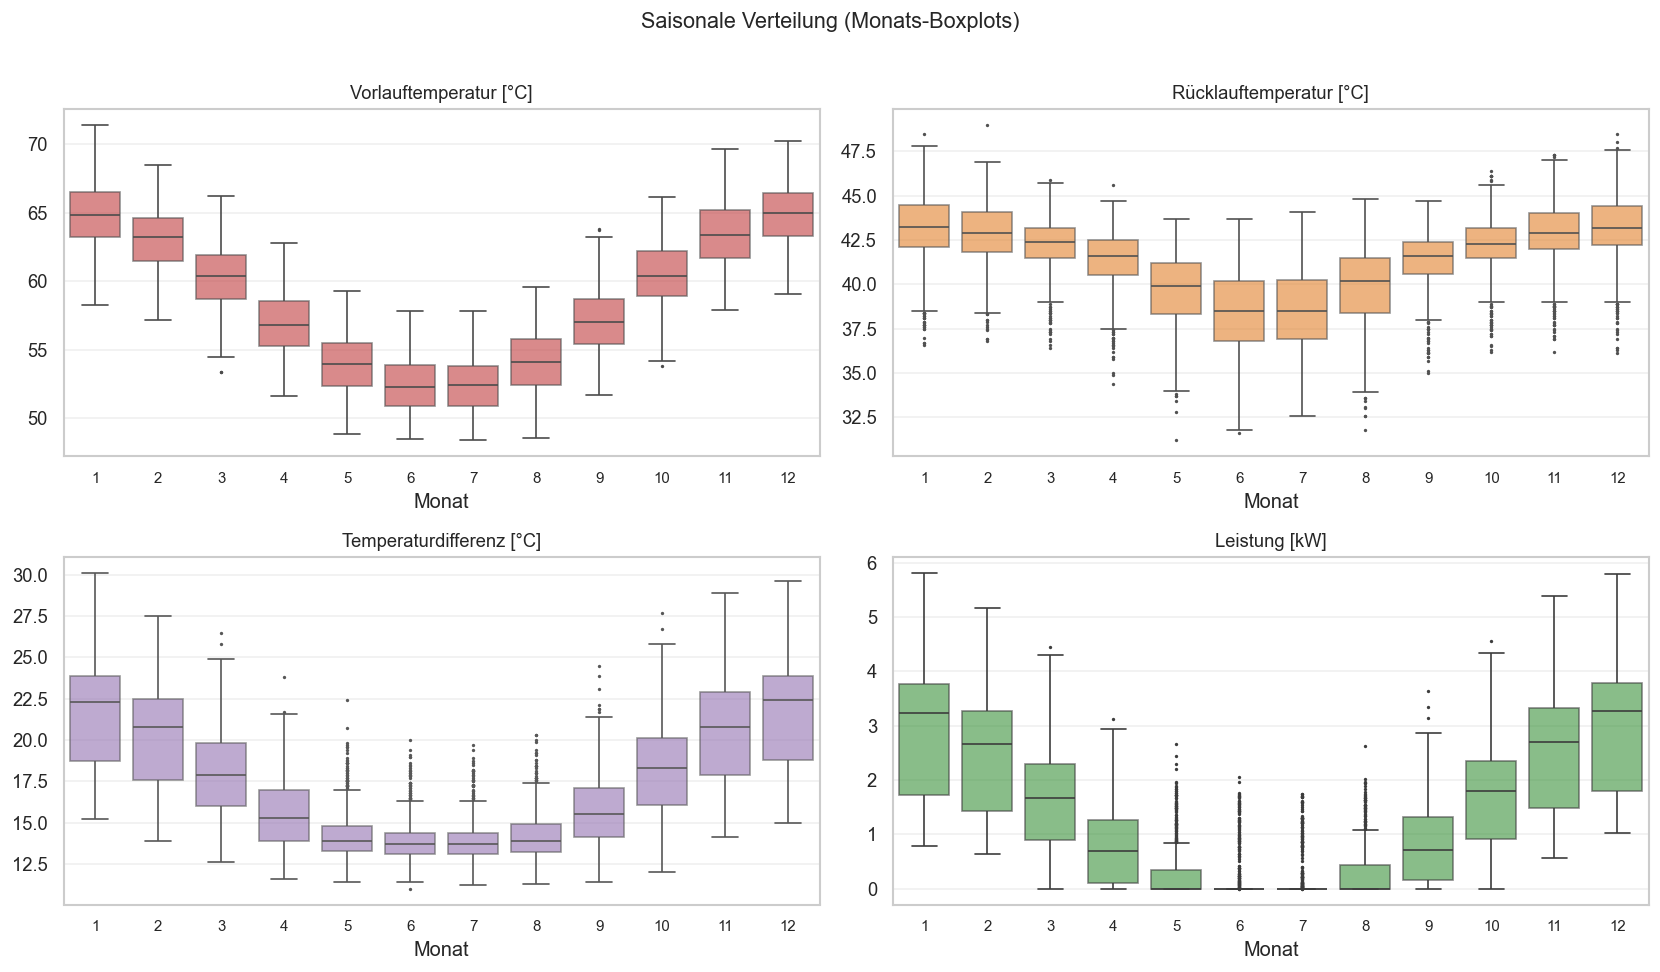

In [37]:
# ── Monats-Boxplots für Temperatur & Leistung ────────────────────────────────
df_plot = df.copy()
df_plot['monat'] = df_plot.index.month
df_plot['monat_name'] = df_plot.index.month_name().str[:3]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

kanale_box = [
    ('temp_flow',   'Vorlauftemperatur [°C]',   '#d62728', axes[0,0]),
    ('temp_return', 'Rücklauftemperatur [°C]',  '#ff7f0e', axes[0,1]),
    ('delta_t',     'Temperaturdifferenz [°C]', '#9467bd', axes[1,0]),
    ('power_kw',    'Leistung [kW]',             '#2ca02c', axes[1,1]),
]

monat_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for col, label, farbe, ax in kanale_box:
    if col not in df_plot.columns:
        ax.set_visible(False)
        continue
    sns.boxplot(data=df_plot, x='monat', y=col, ax=ax,
                color=farbe, fliersize=1)
    # Alpha nachträglich setzen
    for patch in ax.patches:
        patch.set_alpha(0.6)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Monat')
    ax.set_ylabel('')
    ax.set_xticklabels([str(m) for m in range(1, 13)], fontsize=9)

plt.suptitle('Saisonale Verteilung (Monats-Boxplots)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

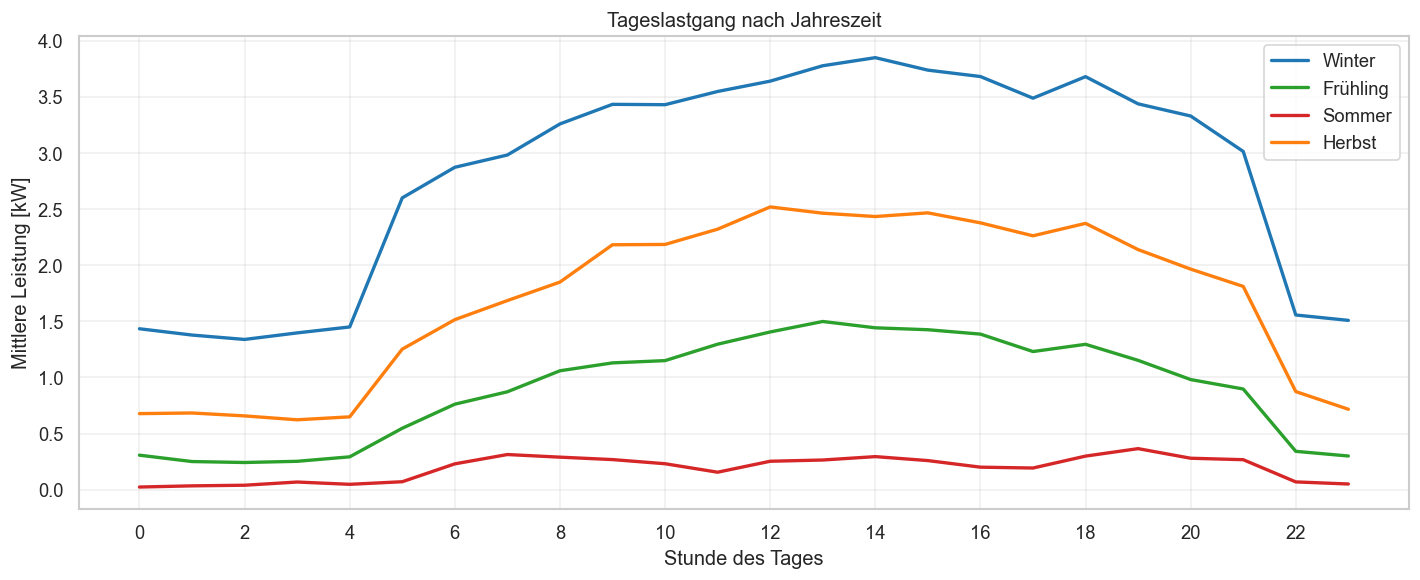

In [38]:
# ── Tageslastgang (Stunden-Profil) ───────────────────────────────────────────
df_plot['stunde'] = df_plot.index.hour
df_plot['jahreszeit'] = pd.cut(
    df_plot.index.month,
    bins=[0, 2, 5, 8, 11, 12],
    labels=['Winter', 'Frühling', 'Sommer', 'Herbst', 'Winter'],
    ordered=False
)

fig, ax = plt.subplots(figsize=(12, 5))
for jz, farbe in zip(['Winter','Frühling','Sommer','Herbst'],
                     ['#1f77b4','#2ca02c','#d62728','#ff7f0e']):
    sub = df_plot[df_plot['jahreszeit'] == jz]
    profil = sub.groupby('stunde')['power_kw'].mean()
    ax.plot(profil.index, profil.values, label=jz, color=farbe, linewidth=2)

ax.set_xlabel('Stunde des Tages')
ax.set_ylabel('Mittlere Leistung [kW]')
ax.set_title('Tageslastgang nach Jahreszeit')
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.show()

## 5 · Hydraulisch-thermische Plausibilität
Prüft die physikalische Konsistenz: Q = ṁ · cₚ · ΔT

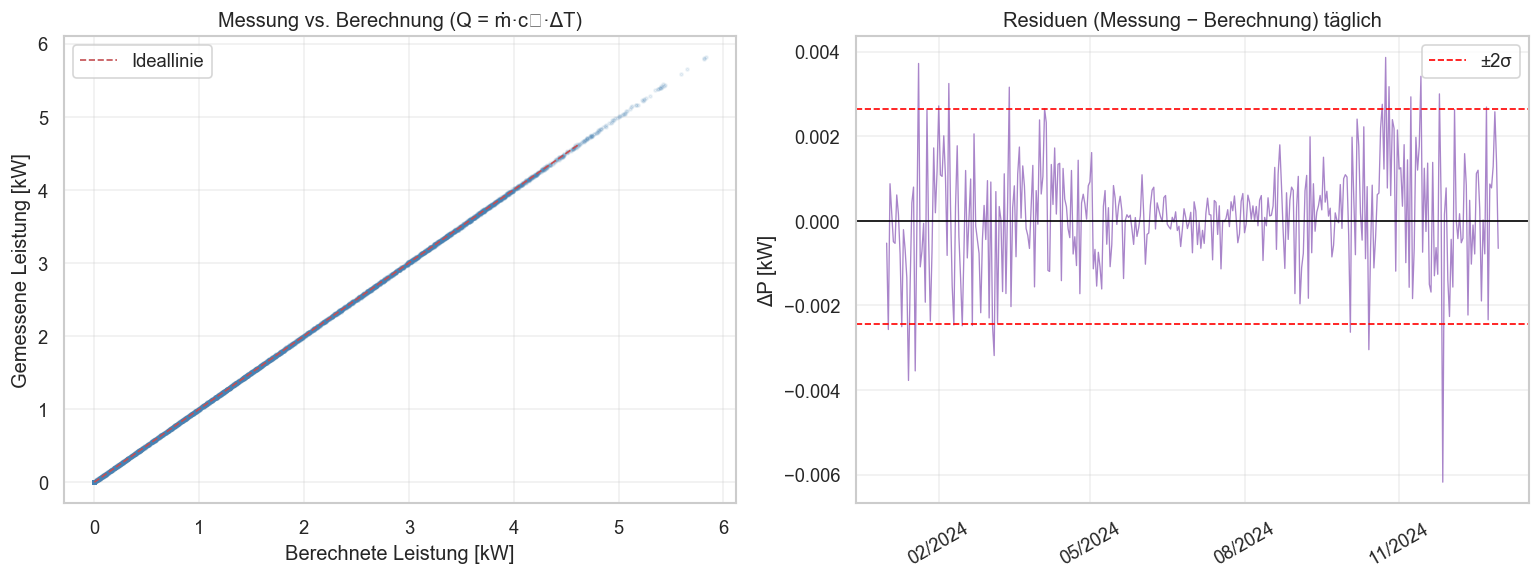

R² (Messung vs. Berechnung): 1.0000
Mittleres Residuum: 0.00 kW
Std. Residuum: 0.01 kW


In [39]:
# ── Berechnete vs. gemessene Leistung ────────────────────────────────────────
# Physikalische Überprüfung: P_calc [kW] = Volumenstrom [l/h] × ΔT [°C] × 1.163 / 1000
# (1.163 = cp_Wasser × Dichte in Wh/(l·K))
if all(c in df.columns for c in ['flow_lh', 'delta_t', 'power_kw']):
    df['power_calc'] = df['flow_lh'] * df['delta_t'] * 1.163 / 1000
    df['power_residual'] = df['power_kw'] - df['power_calc']

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Scatter: gemessen vs. berechnet
    ax = axes[0]
    valide = df[['power_kw', 'power_calc']].dropna()
    lim = max(valide['power_kw'].quantile(0.99), valide['power_calc'].quantile(0.99))
    ax.scatter(valide['power_calc'], valide['power_kw'],
               alpha=0.1, s=3, color='steelblue')
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='Ideallinie')
    ax.set_xlabel('Berechnete Leistung [kW]')
    ax.set_ylabel('Gemessene Leistung [kW]')
    ax.set_title('Messung vs. Berechnung (Q = ṁ·cₚ·ΔT)')
    ax.legend()

    # Residuen-Zeitreihe
    ax2 = axes[1]
    res_tag = df['power_residual'].resample('D').mean()
    ax2.plot(res_tag.index, res_tag.values, color='#9467bd', linewidth=0.8, alpha=0.8)
    ax2.axhline(0, color='black', linewidth=1)
    ax2.axhline(res_tag.mean() + 2*res_tag.std(), color='red', linestyle='--',
                linewidth=1, label='±2σ')
    ax2.axhline(res_tag.mean() - 2*res_tag.std(), color='red', linestyle='--', linewidth=1)
    ax2.set_title('Residuen (Messung − Berechnung) täglich')
    ax2.set_ylabel('ΔP [kW]')
    ax2.legend()
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax2.get_xticklabels(), rotation=30)

    plt.tight_layout()
    plt.show()

    r2 = np.corrcoef(valide['power_calc'], valide['power_kw'])[0, 1]**2
    print(f'R² (Messung vs. Berechnung): {r2:.4f}')
    print(f'Mittleres Residuum: {df["power_residual"].mean():.2f} kW')
    print(f'Std. Residuum: {df["power_residual"].std():.2f} kW')
else:
    print('Spalten für Plausibilitätsprüfung nicht vorhanden.')

## 6 · Korrelationsanalyse

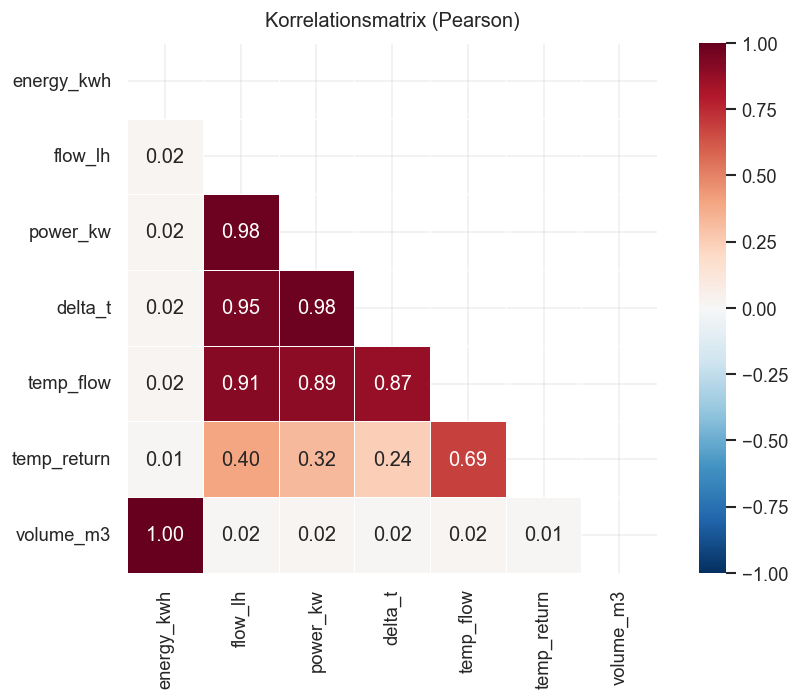

In [40]:
num_cols = [c for c in ['energy_kwh','flow_lh','power_kw','delta_t',
                         'temp_flow','temp_return','volume_m3'] if c in df.columns]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            xticklabels=num_cols, yticklabels=num_cols)
ax.set_title('Korrelationsmatrix (Pearson)', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

## 7 · Einfache Anomalie-Indikatoren (Basis für spätere Detektion)
Statistische Ausreißer als Vorstufe zur formalen Anomalieerkennung.

In [41]:
# ── Z-Score Methode ──────────────────────────────────────────────────────────
ZSCORE_SCHWELLE = 3.0  # Anpassbar

anomalie_flags = pd.DataFrame(index=df.index)

for col in ['power_kw', 'flow_lh', 'delta_t', 'temp_flow', 'temp_return']:
    if col not in df.columns:
        continue
    z = np.abs(stats.zscore(df[col].dropna()))
    flag = pd.Series(z >= ZSCORE_SCHWELLE, index=df[col].dropna().index)
    anomalie_flags[f'{col}_anomalie'] = flag.reindex(df.index, fill_value=False)

# Physikalische Grenzwerte (anpassen!)
anomalie_flags['delta_t_negativ'] = df.get('delta_t', pd.Series(dtype=float)) < 0
anomalie_flags['flow_negativ']    = df.get('flow_lh', pd.Series(dtype=float)) < 0
anomalie_flags['temp_flow_kalt']  = df.get('temp_flow', pd.Series(dtype=float)) < 20

# Gesamtflag: mindestens ein Indikator angeschlagen
anomalie_flags['gesamt'] = anomalie_flags.any(axis=1)

print('=== Anomalie-Zusammenfassung ===')
for col in anomalie_flags.columns:
    n = anomalie_flags[col].sum()
    pct = n / len(anomalie_flags) * 100
    print(f'  {col:<30} {n:>6} Einträge ({pct:.2f}%)')

=== Anomalie-Zusammenfassung ===
  power_kw_anomalie                   6 Einträge (0.07%)
  flow_lh_anomalie                    0 Einträge (0.00%)
  delta_t_anomalie                   14 Einträge (0.16%)
  temp_flow_anomalie                  0 Einträge (0.00%)
  temp_return_anomalie               31 Einträge (0.35%)
  delta_t_negativ                     0 Einträge (0.00%)
  flow_negativ                        0 Einträge (0.00%)
  temp_flow_kalt                      0 Einträge (0.00%)
  gesamt                             46 Einträge (0.53%)


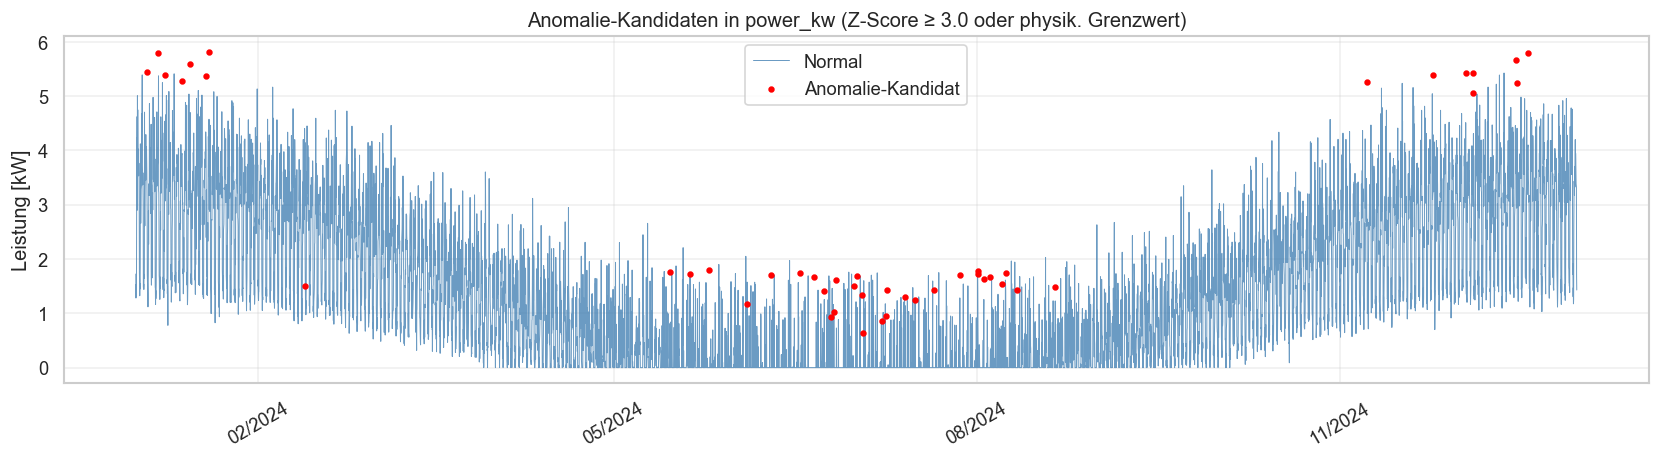


Ergebnis gespeichert: hast_anomalie_flags.csv


In [42]:
kanal = 'power_kw'
if kanal in df.columns:
    normal = df[~anomalie_flags['gesamt']]
    auffaellig = df[anomalie_flags['gesamt']]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(normal.index, normal[kanal],
            color='steelblue', linewidth=0.6, alpha=0.8, label='Normal')
    ax.scatter(auffaellig.index, auffaellig[kanal],
               color='red', s=8, zorder=5, label='Anomalie-Kandidat')
    ax.set_ylabel('Leistung [kW]')
    ax.set_title(f'Anomalie-Kandidaten in {kanal} (Z-Score ≥ {ZSCORE_SCHWELLE} oder physik. Grenzwert)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.get_xticklabels(), rotation=30)
    ax.legend()
    plt.tight_layout()
    plt.show()

export = df.join(anomalie_flags)
export.to_csv('hast_anomalie_flags.csv')
print('\nErgebnis gespeichert: hast_anomalie_flags.csv')

## 8 · Mehrere HASTe vergleichen (optional)
Nur relevant wenn mehr als eine CSV geladen wurde.

In [43]:
if len(dfs) > 1:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    for name, d in dfs.items():
        d_tag = d.resample('D').mean(numeric_only=True)
        if 'temp_flow' in d_tag.columns:
            axes[0].plot(d_tag.index, d_tag['temp_flow'], label=name, linewidth=0.8)
        if 'power_kw' in d_tag.columns:
            axes[1].plot(d_tag.index, d_tag['power_kw'], label=name, linewidth=0.8)

    axes[0].set_ylabel('Vorlauftemperatur [°C]')
    axes[1].set_ylabel('Leistung [kW]')
    axes[0].legend()
    axes[1].legend()
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(axes[1].get_xticklabels(), rotation=30)
    fig.suptitle('HAST-Vergleich (Tagesmittel)', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('Nur ein HAST geladen – Vergleich übersprungen.')

Nur ein HAST geladen – Vergleich übersprungen.


---
## Nächste Schritte

| Schritt | Methode | Python-Bibliothek |
|---------|---------|-------------------|
| Saisonale Zerlegung | STL / Prophet | `statsmodels`, `prophet` |
| Formale Anomalieerkennung | Isolation Forest, LSTM Autoencoder | `sklearn`, `tensorflow` |
| Netzintegration | HAST-Anomalie auf Karte | `geopandas`, `folium` |
| Alerting | Schwellwert-Monitoring | Eigenes Skript / Grafana |
